In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.cluster import KMeans
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report) 

In [19]:
bc=load_breast_cancer()
X,y=bc.data,bc.target
print(X.shape)
print(list(bc.target_names))
print(list(bc.feature_names[:10]))

(569, 30)
[np.str_('malignant'), np.str_('benign')]
[np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness'), np.str_('mean compactness'), np.str_('mean concavity'), np.str_('mean concave points'), np.str_('mean symmetry'), np.str_('mean fractal dimension')]


In [20]:
df=pd.DataFrame(X,columns=bc.feature_names)
df['target']=y
df['diagnosis']=df['target'].map({0:'malignant',1:'benign'})
display(df.head())
print(df['diagnosis'].value_counts)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


<bound method IndexOpsMixin.value_counts of 0      malignant
1      malignant
2      malignant
3      malignant
4      malignant
         ...    
564    malignant
565    malignant
566    malignant
567    malignant
568       benign
Name: diagnosis, Length: 569, dtype: object>


In [21]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print(X_train.shape[0])
print(X_test.shape[0])

455
114


In [22]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [23]:
dt_model=DecisionTreeClassifier(max_depth=3,random_state=42)
dt_model.fit(X_train,y_train)
print(dt_model.get_depth())

3


In [24]:
y_pred_dt=dt_model.predict(X_test)
acc=accuracy_score(y_test,y_pred_dt)
pre=precision_score(y_test,y_pred_dt)
rec=recall_score(y_test,y_pred_dt)
f1=f1_score(y_test,y_pred_dt)
print(acc)
print(pre)
print(rec)
print(f1)

0.9385964912280702
0.9452054794520548
0.9583333333333334
0.9517241379310345


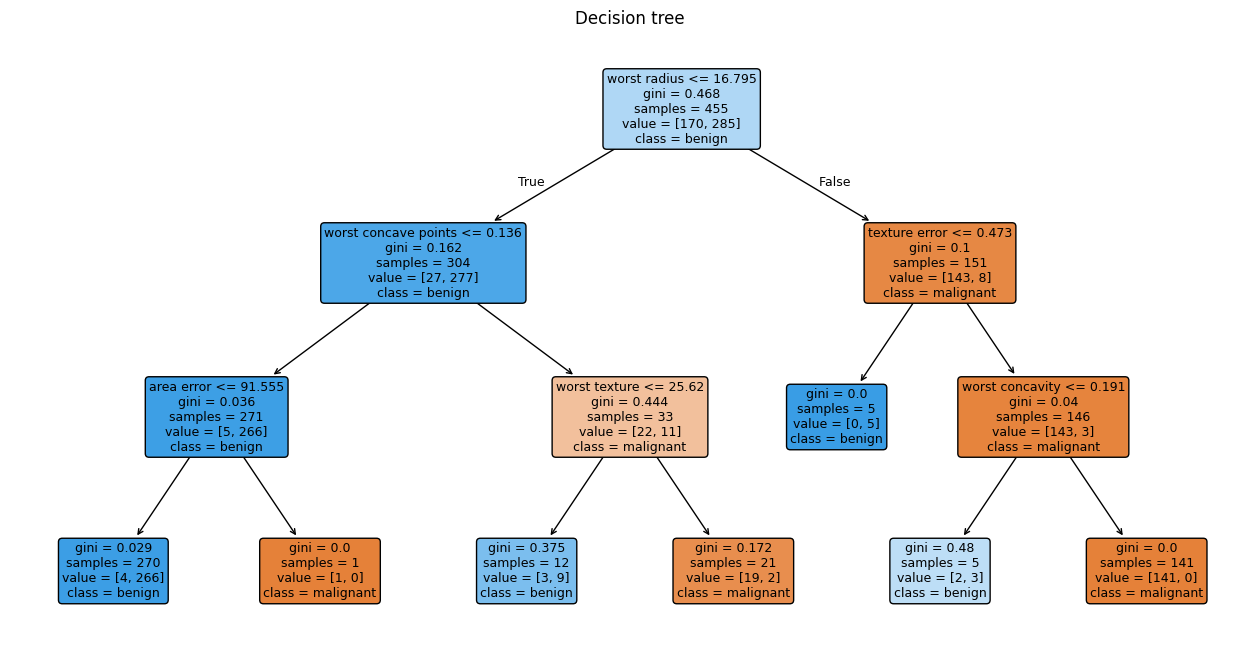

In [26]:
plt.figure(figsize=(16,8))
plot_tree(
    dt_model,
    feature_names=list(bc.feature_names),
    class_names=list(bc.target_names),
    filled=True,rounded=True,fontsize=9
)
plt.title("Decision tree")
plt.show()

In [27]:
df=pd.read_csv("Mall_Customers.csv")

In [28]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [30]:
x_mall=df[['Annual Income (k$)','Spending Score (1-100)']].values

In [31]:
print(x_mall)

[[ 15  39]
 [ 15  81]
 [ 16   6]
 [ 16  77]
 [ 17  40]
 [ 17  76]
 [ 18   6]
 [ 18  94]
 [ 19   3]
 [ 19  72]
 [ 19  14]
 [ 19  99]
 [ 20  15]
 [ 20  77]
 [ 20  13]
 [ 20  79]
 [ 21  35]
 [ 21  66]
 [ 23  29]
 [ 23  98]
 [ 24  35]
 [ 24  73]
 [ 25   5]
 [ 25  73]
 [ 28  14]
 [ 28  82]
 [ 28  32]
 [ 28  61]
 [ 29  31]
 [ 29  87]
 [ 30   4]
 [ 30  73]
 [ 33   4]
 [ 33  92]
 [ 33  14]
 [ 33  81]
 [ 34  17]
 [ 34  73]
 [ 37  26]
 [ 37  75]
 [ 38  35]
 [ 38  92]
 [ 39  36]
 [ 39  61]
 [ 39  28]
 [ 39  65]
 [ 40  55]
 [ 40  47]
 [ 40  42]
 [ 40  42]
 [ 42  52]
 [ 42  60]
 [ 43  54]
 [ 43  60]
 [ 43  45]
 [ 43  41]
 [ 44  50]
 [ 44  46]
 [ 46  51]
 [ 46  46]
 [ 46  56]
 [ 46  55]
 [ 47  52]
 [ 47  59]
 [ 48  51]
 [ 48  59]
 [ 48  50]
 [ 48  48]
 [ 48  59]
 [ 48  47]
 [ 49  55]
 [ 49  42]
 [ 50  49]
 [ 50  56]
 [ 54  47]
 [ 54  54]
 [ 54  53]
 [ 54  48]
 [ 54  52]
 [ 54  42]
 [ 54  51]
 [ 54  55]
 [ 54  41]
 [ 54  44]
 [ 54  57]
 [ 54  46]
 [ 57  58]
 [ 57  55]
 [ 58  60]
 [ 58  46]
 [ 59  55]

In [32]:
scaler_mall=StandardScaler()
x_mall_scaled=scaler_mall.fit_transform(x_mall)
print(x_mall_scaled.mean(axis=0).round(3))
print(x_mall_scaled.std(axis=0).round(3))


[-0. -0.]
[1. 1.]


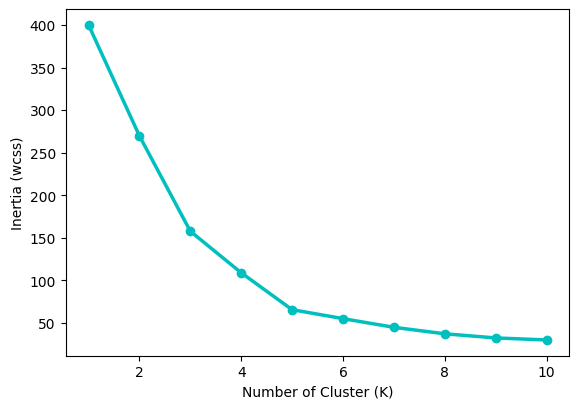

In [33]:
inertias=[]
for k in range(1,11):
    km=KMeans(n_clusters=k,random_state=42,n_init=10)
    km.fit(x_mall_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(6.5,4.5))
plt.plot(range(1,11),inertias,marker="o",color="c",linewidth=2.5)
plt.xlabel("Number of Cluster (K)")
plt.ylabel("Inertia (wcss)")
plt.show()

In [35]:
k_final=5
kmeans=KMeans(n_clusters=k_final,random_state=42,n_init=10)
cluster_labels=kmeans.fit_predict(x_mall_scaled)
df['Cluster']=cluster_labels
print(df['Cluster'].value_counts().sort_index())


Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


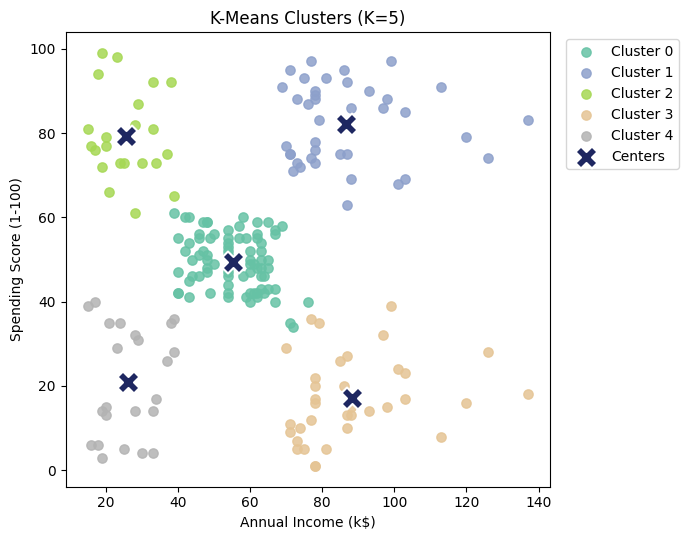

In [37]:
centers_original_scale = scaler_mall.inverse_transform(kmeans.cluster_centers_)

plt.figure(figsize=(7, 5.5))
colors = plt.cm.Set2(np.linspace(0, 1, k_final))
for c in range(k_final):
    subset = df[df["Cluster"] == c]
    plt.scatter(subset["Annual Income (k$)"], subset["Spending Score (1-100)"],
                s=45, color=colors[c], label=f"Cluster {c}", alpha=0.85)
plt.scatter(centers_original_scale[:, 0], centers_original_scale[:, 1],
            marker="X", s=250, color="#1E2761", edgecolor="white", linewidth=1.5, label="Centers", zorder=5)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title(f"K-Means Clusters (K={k_final})")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()